In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, classification_report)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign (sklearn encoding)

# Map to the M/B convention used in the dataset description
target_names = {0: "Malignant", 1: "Benign"}

print("Dataset shape:", X.shape)
print("Target classes:", dict(zip(data.target_names, [0, 1])))
X.head()


Dataset shape: (569, 30)
Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(X.describe().T[["mean", "std", "min", "max"]])
print("\nMissing values per column:\n", X.isnull().sum().sum(), "total missing values")


                               mean         std         min         max
mean radius               14.127292    3.524049    6.981000    28.11000
mean texture              19.289649    4.301036    9.710000    39.28000
mean perimeter            91.969033   24.298981   43.790000   188.50000
mean area                654.889104  351.914129  143.500000  2501.00000
mean smoothness            0.096360    0.014064    0.052630     0.16340
mean compactness           0.104341    0.052813    0.019380     0.34540
mean concavity             0.088799    0.079720    0.000000     0.42680
mean concave points        0.048919    0.038803    0.000000     0.20120
mean symmetry              0.181162    0.027414    0.106000     0.30400
mean fractal dimension     0.062798    0.007060    0.049960     0.09744
radius error               0.405172    0.277313    0.111500     2.87300
texture error              1.216853    0.551648    0.360200     4.88500
perimeter error            2.866059    2.021855    0.757000    2

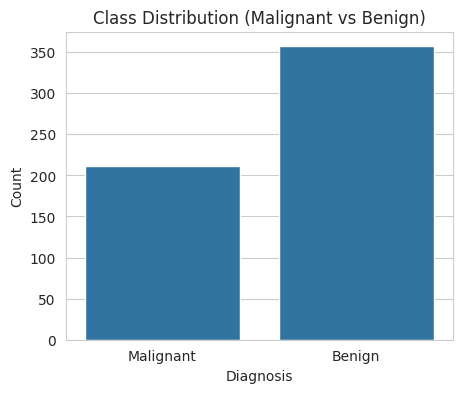

target
Benign       357
Malignant    212
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(x=y.map(target_names))
plt.title("Class Distribution (Malignant vs Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

print(y.map(target_names).value_counts())


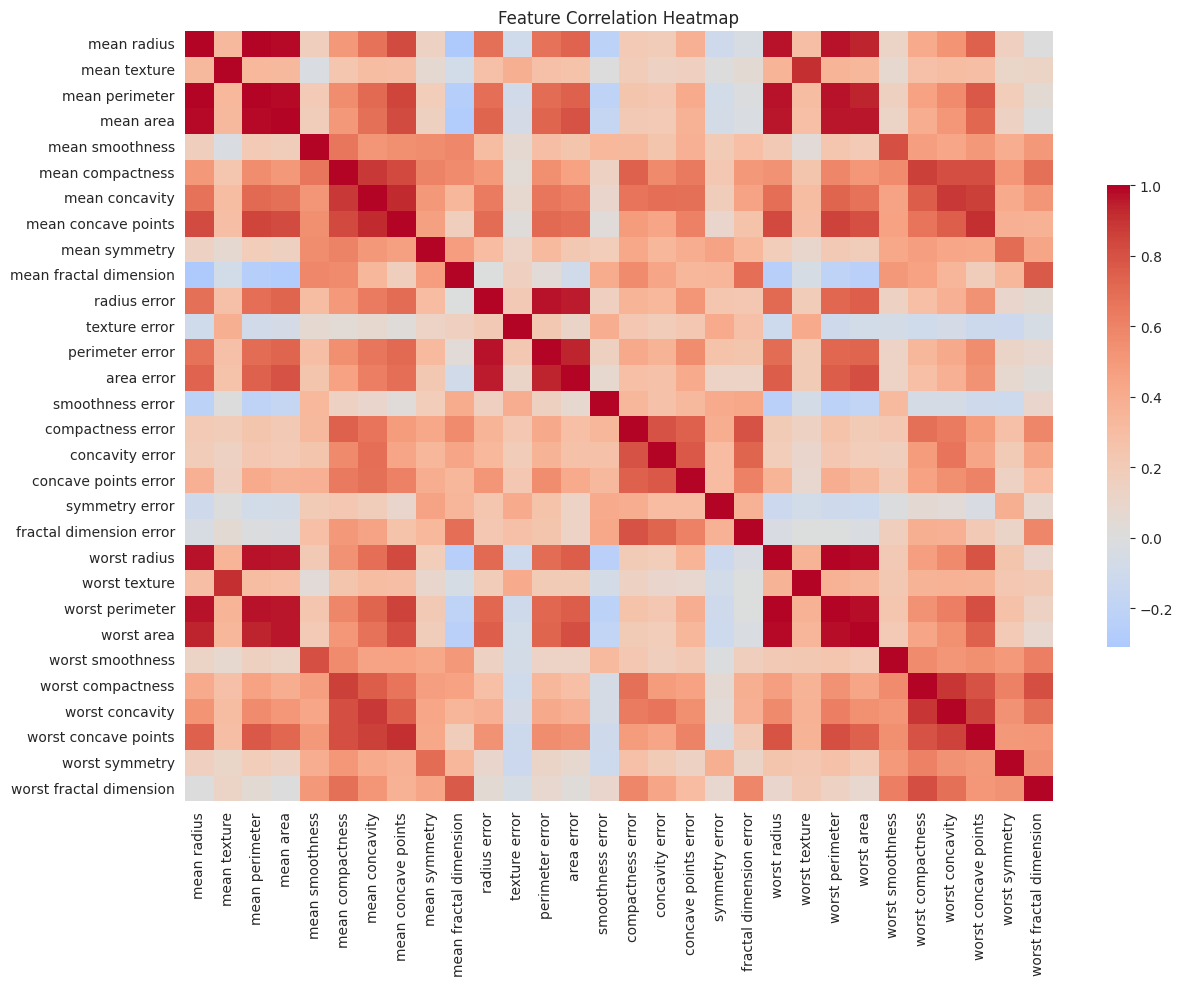

In [5]:
plt.figure(figsize=(14, 10))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.6})
plt.title("Feature Correlation Heatmap")
plt.show()


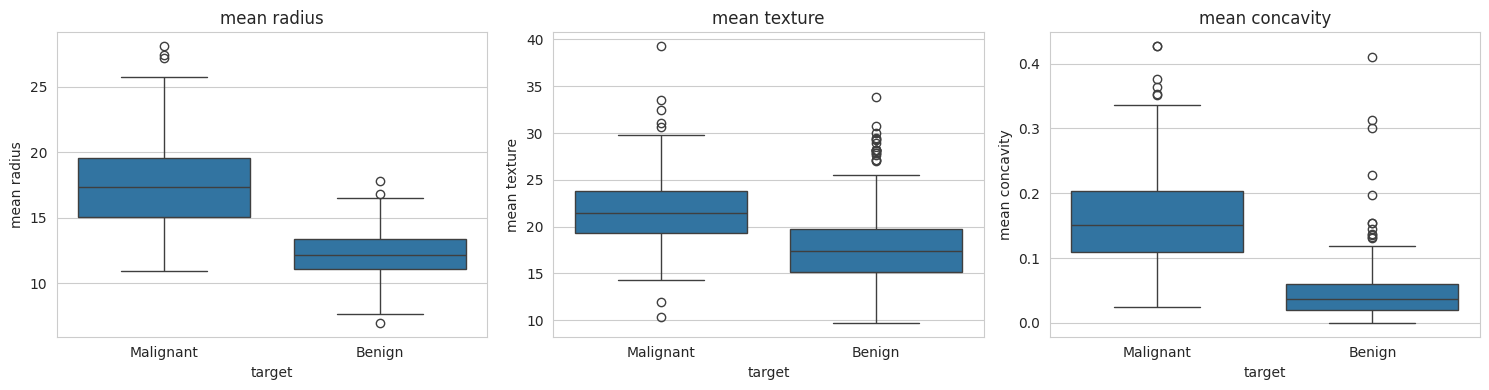

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["mean radius", "mean texture", "mean concavity"]):
    sns.boxplot(x=y.map(target_names), y=X[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (455, 30)  Test shape: (114, 30)


In [8]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

bagging_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
bagging_clf = BaggingClassifier(estimator=bagging_base, random_state=RANDOM_STATE)

bagging_param_grid = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.75, 1.0],
    "max_features": [0.5, 0.75, 1.0],
}

bagging_grid = GridSearchCV(
    bagging_clf, bagging_param_grid, cv=cv5,
    scoring="accuracy", n_jobs=-1
)
bagging_grid.fit(X_train_scaled, y_train)

print("Best Bagging Params:", bagging_grid.best_params_)
print("Best CV Accuracy: {:.4f}".format(bagging_grid.best_score_))

best_bagging = bagging_grid.best_estimator_


Best Bagging Params: {'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 50}
Best CV Accuracy: 0.9604


In [9]:
bagging_results = pd.DataFrame(bagging_grid.cv_results_)
bagging_results["mean_f1"] = cross_val_score(
    BaggingClassifier(estimator=bagging_base, random_state=RANDOM_STATE,
                       n_estimators=bagging_grid.best_params_["n_estimators"],
                       max_samples=bagging_grid.best_params_["max_samples"],
                       max_features=bagging_grid.best_params_["max_features"]),
    X_train_scaled, y_train, cv=cv5, scoring="f1"
).mean()

bagging_summary = bagging_results[["param_n_estimators", "param_max_samples", "param_max_features",
                                    "mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False).head(10)
bagging_summary.columns = ["n_estimators", "max_samples", "max_features", "Avg CV Accuracy", "Std"]
bagging_summary["Avg CV Accuracy (%)"] = bagging_summary["Avg CV Accuracy"] * 100
bagging_summary


,n_estimators,max_samples,max_features,Avg CV Accuracy,Std,Avg CV Accuracy (%)
1,50,0.50,0.50,0.960440,0.017855,96.043956
16,50,1.00,0.75,0.960440,0.017855,96.043956
7,50,1.00,0.50,0.960440,0.016447,96.043956
8,100,1.00,0.50,0.960440,0.011207,96.043956
21,10,0.75,1.00,0.958242,0.012815,95.824176
6,10,1.00,0.50,0.956044,0.013900,95.604396
5,100,0.75,0.50,0.956044,0.018388,95.604396
13,50,0.75,0.75,0.956044,0.017024,95.604396
15,10,1.00,0.75,0.956044,0.024076,95.604396
17,100,1.00,0.75,0.956044,0.018388,95.604396


In [ ]:
# AdaBoost
adaboost_clf = AdaBoostClassifier(random_state=RANDOM_STATE)

adaboost_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
}

adaboost_grid = GridSearchCV(adaboost_clf, adaboost_param_grid, cv=cv5, scoring="accuracy", n_jobs=-1)
adaboost_grid.fit(X_train_scaled, y_train)

print("Best AdaBoost Params:", adaboost_grid.best_params_)
print("Best CV Accuracy: {:.4f}".format(adaboost_grid.best_score_))

best_adaboost = adaboost_grid.best_estimator_


Best AdaBoost Params: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV Accuracy: 0.9802


In [ ]:
# Gradient Boosting
gb_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4],
}

gb_grid = GridSearchCV(gb_clf, gb_param_grid, cv=cv5, scoring="accuracy", n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)

print("Best Gradient Boosting Params:", gb_grid.best_params_)
print("Best CV Accuracy: {:.4f}".format(gb_grid.best_score_))

best_gb = gb_grid.best_estimator_


Best Gradient Boosting Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best CV Accuracy: 0.9736


In [12]:
boosting_results = pd.DataFrame(gb_grid.cv_results_)
boosting_summary = boosting_results[["param_n_estimators", "param_learning_rate", "param_max_depth",
                                      "mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False).head(10)
boosting_summary.columns = ["n_estimators", "learning_rate", "max_depth", "Avg CV Accuracy", "Std"]
boosting_summary["Avg CV Accuracy (%)"] = boosting_summary["Avg CV Accuracy"] * 100
boosting_summary


,n_estimators,learning_rate,max_depth,Avg CV Accuracy,Std,Avg CV Accuracy (%)
23,200,0.2,3,0.973626,0.014906,97.362637
20,200,0.2,2,0.971429,0.020382,97.142857
19,100,0.2,2,0.969231,0.018906,96.923077
11,200,0.1,2,0.967033,0.015541,96.703297
22,100,0.2,3,0.964835,0.012815,96.483516
18,50,0.2,2,0.962637,0.017855,96.263736
10,100,0.1,2,0.962637,0.013187,96.263736
14,200,0.1,3,0.960440,0.016447,96.043956
16,100,0.1,4,0.960440,0.019160,96.043956
24,50,0.2,4,0.958242,0.016150,95.824176


In [13]:
base_learners = [
    ("svm", SVC(probability=True, random_state=RANDOM_STATE)),
    ("nb", GaussianNB()),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
]

meta_learner = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=cv5,
    n_jobs=-1
)

stacking_cv_scores = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=cv5, scoring="accuracy")
stacking_cv_f1 = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=cv5, scoring="f1")

print("Stacked Ensemble 5-fold CV Accuracy: {:.4f} (+/- {:.4f})".format(
    stacking_cv_scores.mean(), stacking_cv_scores.std()))
print("Stacked Ensemble 5-fold CV F1 Score: {:.4f}".format(stacking_cv_f1.mean()))

stacking_clf.fit(X_train_scaled, y_train)


Stacked Ensemble 5-fold CV Accuracy: 0.9648 (+/- 0.0189)
Stacked Ensemble 5-fold CV F1 Score: 0.9718


StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('svm', SVC(probability=True, random_state=42)),
                               ('nb', GaussianNB()),
                               ('dt', DecisionTreeClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

In [14]:
stacking_summary = pd.DataFrame({
    "Base Models": ["SVM + Naive Bayes + Decision Tree"],
    "Meta Learner": ["Logistic Regression"],
    "Avg CV Accuracy (%)": [stacking_cv_scores.mean() * 100],
    "Avg CV F1 Score": [stacking_cv_f1.mean()],
})
stacking_summary


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.483516,0.971796


In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    print(f"\n {name} ")
    print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

    return {"Model": name, "Accuracy (%)": acc * 100, "Precision": prec,
            "Recall": rec, "F1 Score": f1, "AUC": auc}, y_pred, y_proba

results = []
predictions = {}

for name, model in [("Bagging", best_bagging), ("Boosting (Gradient Boosting)", best_gb),
                     ("Stacked Ensemble", stacking_clf)]:
    res, y_pred, y_proba = evaluate_model(name, model, X_test_scaled, y_test)
    results.append(res)
    predictions[name] = (y_pred, y_proba)

comparison_df = pd.DataFrame(results)
comparison_df



--- Bagging ---
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Boosting (Gradient Boosting) ---
              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Stacked Ensemble ---
              precision    recall  f1-score   support

   Malignant       0.97      0.93      0.95        42
      Benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96    

,Model,Accuracy (%),Precision,Recall,F1 Score,AUC
0,Bagging,95.614035,0.958904,0.972222,0.965517,0.993056
1,Boosting (Gradient Boosting),95.614035,0.946667,0.986111,0.965986,0.995701
2,Stacked Ensemble,96.491228,0.959459,0.986111,0.972603,0.993056


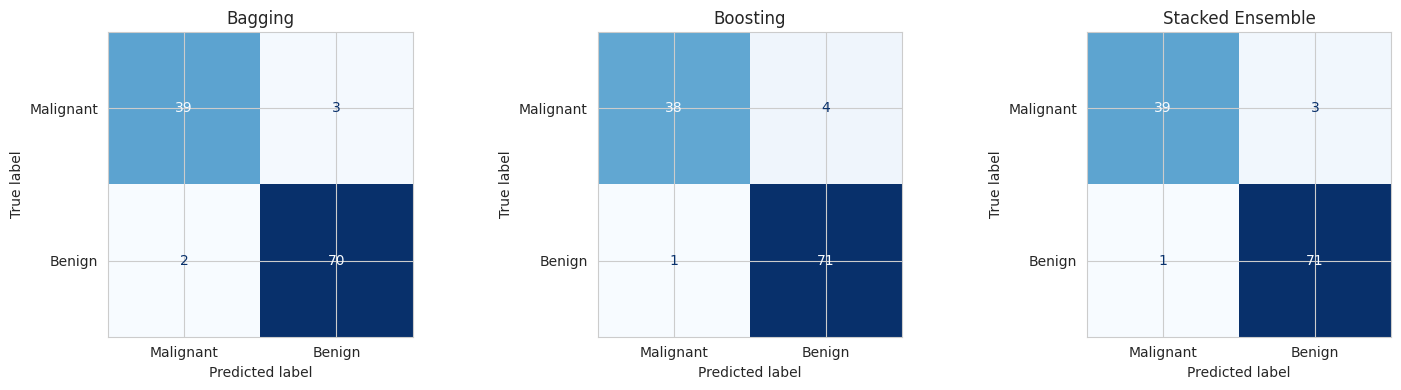

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, [("Bagging", best_bagging), ("Boosting", best_gb),
                                     ("Stacked Ensemble", stacking_clf)]):
    y_pred, _ = predictions[name] if name in predictions else predictions["Boosting (Gradient Boosting)"]
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


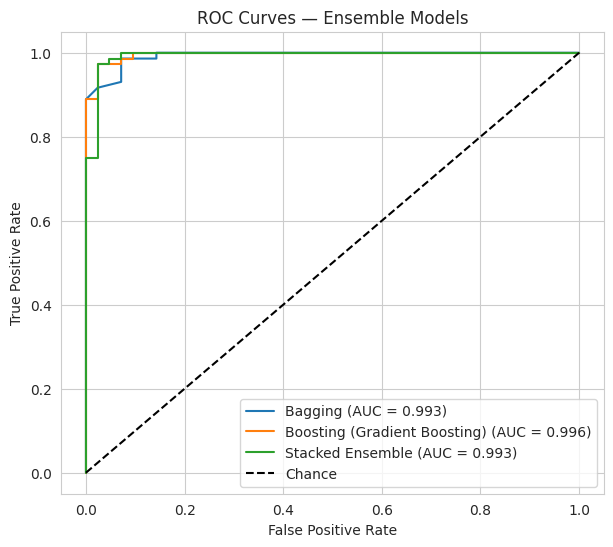

In [17]:
plt.figure(figsize=(7, 6))
for name, model in [("Bagging", best_bagging), ("Boosting (Gradient Boosting)", best_gb),
                     ("Stacked Ensemble", stacking_clf)]:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Ensemble Models")
plt.legend(loc="lower right")
plt.show()


In [18]:
comparison_display = comparison_df.copy()
comparison_display[["Accuracy (%)", "Precision", "Recall", "F1 Score", "AUC"]] = \
    comparison_display[["Accuracy (%)", "Precision", "Recall", "F1 Score", "AUC"]].round(4)
comparison_display


,Model,Accuracy (%),Precision,Recall,F1 Score,AUC
0,Bagging,95.6140,0.9589,0.9722,0.9655,0.9931
1,Boosting (Gradient Boosting),95.6140,0.9467,0.9861,0.9660,0.9957
2,Stacked Ensemble,96.4912,0.9595,0.9861,0.9726,0.9931


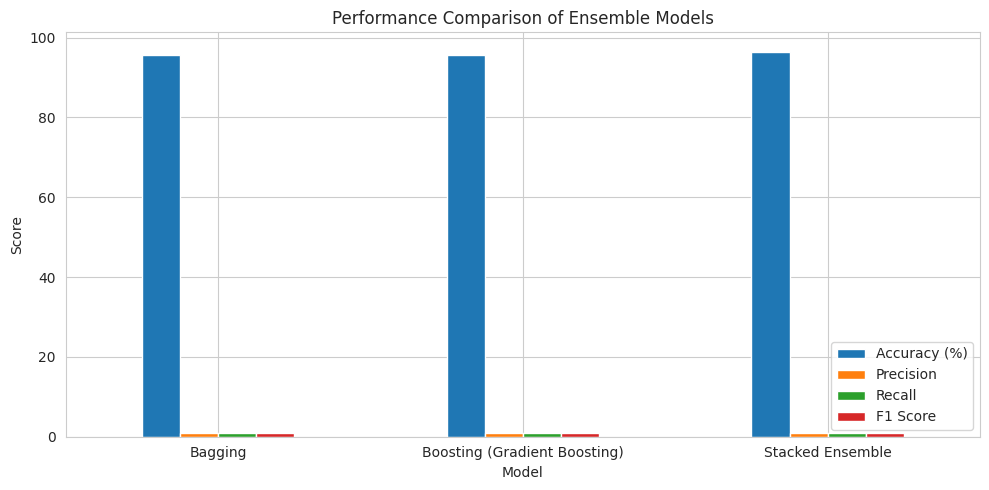

In [19]:
comparison_df.set_index("Model")[["Accuracy (%)", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
plt.title("Performance Comparison of Ensemble Models")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
